# Data Cleaning - Crop Disease Dataset
This notebook demonstrates data cleaning and validation for the crop disease detection system

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import hashlib

DATA_PATH = r'c:\Users\Administrator\Desktop\AIC\plantvillage dataset\color'
OUTPUT_CSV = r'c:\Users\Administrator\Desktop\AIC\data\processed\dataset_metadata.csv'

## Step 1: Generate Metadata CSV from Images

In [2]:
# Extract metadata from all images
data = []

for class_folder in os.listdir(DATA_PATH):
    class_path = os.path.join(DATA_PATH, class_folder)
    if not os.path.isdir(class_path):
        continue
    
    # Parse crop and disease from folder name
    parts = class_folder.split('___')
    crop = parts[0] if len(parts) > 0 else 'Unknown'
    disease = parts[1] if len(parts) > 1 else 'Unknown'
    
    for img_file in os.listdir(class_path):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        
        img_path = os.path.join(class_path, img_file)
        
        try:
            img = cv2.imread(img_path)
            if img is not None:
                height, width, channels = img.shape
                file_size = os.path.getsize(img_path) / 1024  # KB
                
                data.append({
                    'image_path': img_path,
                    'filename': img_file,
                    'crop': crop,
                    'disease': disease,
                    'class_label': class_folder,
                    'height': height,
                    'width': width,
                    'channels': channels,
                    'file_size_kb': file_size,
                    'is_valid': True
                })
        except:
            data.append({
                'image_path': img_path,
                'filename': img_file,
                'crop': crop,
                'disease': disease,
                'class_label': class_folder,
                'height': None,
                'width': None,
                'channels': None,
                'file_size_kb': None,
                'is_valid': False
            })

df = pd.DataFrame(data)
print(f"Generated metadata for {len(df)} images")
df.head()

Generated metadata for 54305 images


,image_path,filename,crop,disease,class_label,height,width,channels,file_size_kb,is_valid
0,c:\Users\Administrator\Desktop\AIC\plantvillag...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,Apple,Apple_scab,Apple___Apple_scab,256,256,3,9.390625,True
1,c:\Users\Administrator\Desktop\AIC\plantvillag...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,Apple,Apple_scab,Apple___Apple_scab,256,256,3,9.871094,True
2,c:\Users\Administrator\Desktop\AIC\plantvillag...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,Apple,Apple_scab,Apple___Apple_scab,256,256,3,11.723633,True
3,c:\Users\Administrator\Desktop\AIC\plantvillag...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,Apple,Apple_scab,Apple___Apple_scab,256,256,3,19.017578,True
4,c:\Users\Administrator\Desktop\AIC\plantvillag...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,Apple,Apple_scab,Apple___Apple_scab,256,256,3,8.688477,True


## Step 2: Data Quality Assessment

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
image_path      0
filename        0
crop            0
disease         0
class_label     0
height          0
width           0
channels        0
file_size_kb    0
is_valid        0
dtype: int64

Total missing: 0


In [4]:
# Check for invalid images
invalid_count = (~df['is_valid']).sum()
print(f"Invalid/Corrupted images: {invalid_count}")

if invalid_count > 0:
    print("\nInvalid images:")
    print(df[~df['is_valid']][['filename', 'class_label']])

Invalid/Corrupted images: 0


In [5]:
# Check for duplicate filenames
duplicates = df[df.duplicated(subset=['filename'], keep=False)]
print(f"Duplicate filenames: {len(duplicates)}")

if len(duplicates) > 0:
    print(duplicates[['filename', 'class_label']].head(10))

Duplicate filenames: 0


## Step 3: Detect and Handle Outliers

In [4]:
# Analyze image dimensions
df_valid = df[df['is_valid']].copy()

print("Image Dimension Statistics:")
print(df_valid[['height', 'width', 'file_size_kb']].describe())

Image Dimension Statistics:
        height    width  file_size_kb
count  54305.0  54305.0  54305.000000
mean     256.0    256.0     15.299606
std        0.0      0.0      4.319369
min      256.0    256.0      3.359375
25%      256.0    256.0     11.994141
50%      256.0    256.0     15.582031
75%      256.0    256.0     18.602539
max      256.0    256.0    118.800781


In [6]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

# Check for dimension outliers
height_outliers = detect_outliers_iqr(df_valid, 'height')
width_outliers = detect_outliers_iqr(df_valid, 'width')
size_outliers = detect_outliers_iqr(df_valid, 'file_size_kb')

print(f"Height outliers: {len(height_outliers)}")
print(f"Width outliers: {len(width_outliers)}")
print(f"File size outliers: {len(size_outliers)}")

Height outliers: 0
Width outliers: 0
File size outliers: 2


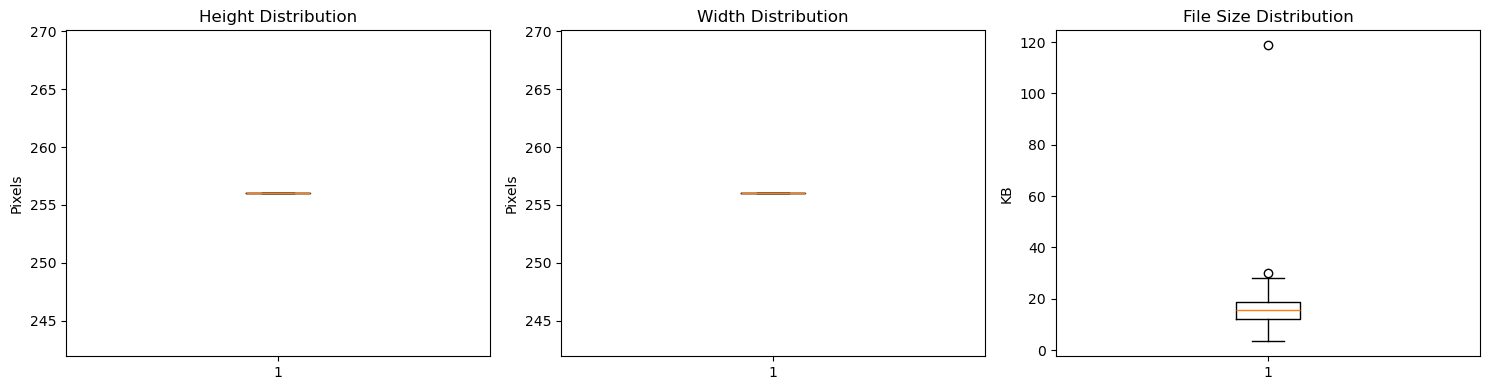

In [8]:
# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(df_valid['height'])
axes[0].set_title('Height Distribution')
axes[0].set_ylabel('Pixels')

axes[1].boxplot(df_valid['width'])
axes[1].set_title('Width Distribution')
axes[1].set_ylabel('Pixels')

axes[2].boxplot(df_valid['file_size_kb'])
axes[2].set_title('File Size Distribution')
axes[2].set_ylabel('KB')

plt.tight_layout()
plt.show()

## Step 4: Handle Class Imbalance

In [9]:
# Analyze class distribution
class_dist = df_valid['class_label'].value_counts()
print("Class Distribution:")
print(class_dist)

# Calculate imbalance ratio
max_samples = class_dist.max()
min_samples = class_dist.min()
imbalance_ratio = max_samples / min_samples
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Max class: {max_samples} samples")
print(f"Min class: {min_samples} samples")

Class Distribution:
class_label
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Pepper,_bell___healthy                                1478
Tomato___Target_Spot                                  1404
Grape___Esca_(Black_Measles)                          1383
Corn_(maize)___Common_rust_                           1192
Grape___Black_rot       

In [11]:
# Identify underrepresented classes (< 500 samples)
underrepresented = class_dist[class_dist < 500]
print(f"\nUnderrepresented classes ({len(underrepresented)}):")
print(underrepresented)

# Mark for augmentation
df_valid['needs_augmentation'] = df_valid['class_label'].isin(underrepresented.index)


Underrepresented classes (7):
class_label
Strawberry___healthy            456
Grape___healthy                 423
Tomato___Tomato_mosaic_virus    373
Raspberry___healthy             371
Peach___healthy                 360
Apple___Cedar_apple_rust        275
Potato___healthy                152
Name: count, dtype: int64


## Step 5: Data Cleaning - Remove Invalid Data

In [12]:
# Remove invalid images
df_clean = df[df['is_valid']].copy()
print(f"Removed {len(df) - len(df_clean)} invalid images")

# Remove extreme outliers (optional)
# Keep images within reasonable size range
df_clean = df_clean[
    (df_clean['height'] >= 50) & 
    (df_clean['width'] >= 50) &
    (df_clean['file_size_kb'] > 1)
]
print(f"After removing extreme outliers: {len(df_clean)} images")

Removed 0 invalid images
After removing extreme outliers: 54305 images


## Step 6: Feature Engineering

In [13]:
# Add derived features
df_clean['aspect_ratio'] = df_clean['width'] / df_clean['height']
df_clean['total_pixels'] = df_clean['width'] * df_clean['height']
df_clean['is_healthy'] = df_clean['disease'].str.lower() == 'healthy'

# Categorize crops
df_clean['crop_category'] = df_clean['crop'].apply(lambda x: 
    'Fruit' if x in ['Apple', 'Orange', 'Peach', 'Strawberry', 'Blueberry', 'Cherry_(including_sour)', 'Raspberry', 'Grape'] 
    else 'Vegetable' if x in ['Tomato', 'Potato', 'Pepper,_bell', 'Squash']
    else 'Grain' if x in ['Corn_(maize)', 'Soybean']
    else 'Other'
)

print("New features added:")
print(df_clean[['aspect_ratio', 'total_pixels', 'is_healthy', 'crop_category']].head())

New features added:
   aspect_ratio  total_pixels  is_healthy crop_category
0           1.0         65536       False         Fruit
1           1.0         65536       False         Fruit
2           1.0         65536       False         Fruit
3           1.0         65536       False         Fruit
4           1.0         65536       False         Fruit


## Step 7: Save Cleaned Dataset

In [14]:
# Save to CSV
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df_clean.to_csv(OUTPUT_CSV, index=False)
print(f"Cleaned dataset saved to: {OUTPUT_CSV}")
print(f"Total records: {len(df_clean)}")

Cleaned dataset saved to: c:\Users\Administrator\Desktop\AIC\data\processed\dataset_metadata.csv
Total records: 54305


## Step 8: Cleaning Summary Report

In [15]:
print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"Original images: {len(df)}")
print(f"Invalid images removed: {len(df) - len(df_clean)}")
print(f"Final clean dataset: {len(df_clean)}")
print(f"\nClasses: {df_clean['class_label'].nunique()}")
print(f"Crops: {df_clean['crop'].nunique()}")
print(f"Diseases: {df_clean['disease'].nunique()}")
print(f"\nHealthy samples: {df_clean['is_healthy'].sum()}")
print(f"Diseased samples: {(~df_clean['is_healthy']).sum()}")

# Add needs_augmentation column
class_dist = df_clean['class_label'].value_counts()
underrepresented = class_dist[class_dist < 500]
df_clean['needs_augmentation'] = df_clean['class_label'].isin(underrepresented.index)

print(f"Classes needing augmentation: {len(underrepresented)}")


print("\n" + "=" * 60)


DATA CLEANING SUMMARY
Original images: 54305
Invalid images removed: 0
Final clean dataset: 54305

Classes: 38
Crops: 14
Diseases: 21

Healthy samples: 15084
Diseased samples: 39221
Classes needing augmentation: 7

